## SITCOM-2049



In [93]:
#Setting packages
import asyncio
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import os
import sys
import time
import warnings
import seaborn as sns
import datetime as dt
from scipy import stats
from matplotlib.dates import DateFormatter
from astropy.table import Table, join
from statsmodels.tsa.seasonal import seasonal_decompose
from sklearn.ensemble import IsolationForest
from sklearn.cluster import AgglomerativeClustering
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from scipy.cluster.hierarchy import dendrogram, linkage
from lsst.utils.packages import getEnvironmentPackages
#%matplotlib widget

from astropy.time import Time, TimeDelta
from lsst_efd_client.efd_helper import merge_packed_time_series
from lsst.meas.algorithms.installGaussianPsf import FwhmPerSigma
from lsst.daf.butler import Butler 
#from tqdm.notebook import tqdm

# Ignore the many warning messages from ``merge_packed_time_series``
warnings.simplefilter(action="ignore", category=FutureWarning)

#-------Clients
from lsst_efd_client import EfdClient
client = EfdClient("usdf_efd")
from lsst.summit.utils.efdUtils import (
    getEfdData,
    getDayObsEndTime,
    getDayObsForTime,
    getDayObsStartTime,
    makeEfdClient,
)

#from lsst.summit.utils.efdUtils import makeEfdClient
#client = makeEfdClient()

#from lsst.summit.utils import ConsDbClient
#os.environ["no_proxy"] += ",.consdb"
#url="http://consdb-pq.consdb:8080/consdb"
#consdb=ConsDbClient(url)
#-------Clients



In [94]:
#Initialize an EFD client
efd_client = makeEfdClient()

In [95]:
#Observation time
## We go a month in time -- could go largher 
start_time = Time("2025-11-01T00:00:00Z", scale="utc")
end_time = Time("2025-11-30T23:59:00Z", scale="utc")

In [137]:
## pullling a subset of columns from the EFD 
df_script = getEfdData(
             client=efd_client,
             topic="lsst.sal.ScriptQueue.logevent_script",
             #columns=["*"],         
    columns=["cmdId","salIndex","path","scriptState", "scriptSalIndex","processState","timestampProcessStart", "timestampConfigureStart", "timestampConfigureEnd", "timestampRunStart" ],
             begin=start_time,
             end=end_time,
)

In [162]:
# filter: MTQ and selecting entries for a common cmdId

df_filt=df_script[(df_script['salIndex']==1)].groupby('cmdId').tail(1) ## 

### NOTEs: 
#### 1. Script SAL ids are NOT unique because they get recycled every time the scriptQ gets restarted (no cadence of this!) 
#### 2. When a script is terminated-- it turns that the delta_t (i.e total time between configure start to end ) goes -1.7e-9. That is becaise there is NO timestanp for ConfigureEnd 

In [163]:
#df_filt['configure_start']=pd.to_datetime(df_filt['timestampConfigureStart'], unit='s')
#df_filt['configure_end']=pd.to_datetime(df_filt['timestampConfigureEnd'], unit='s')
df_filt['tdelta_config']= (df_filt['timestampConfigureEnd']-df_filt['timestampConfigureStart'])
df_filt['weekday']=df_filt.index.day_name() ## extarcting week day from the datetime object 
df_filt['tod']=df_filt.index.time # extarcting time from the date-time index 

In [164]:
df_filt[df_filt['tdelta_config']<0]

,cmdId,salIndex,path,scriptState,scriptSalIndex,processState,timestampProcessStart,timestampConfigureStart,timestampConfigureEnd,timestampRunStart,tdelta_config,weekday,tod
2025-11-01 06:46:21.022002+00:00,30876755,1,maintel/point_azel.py,1,104810,7,1.761980e+09,1.761980e+09,0.0,0.0,-1.761980e+09,Saturday,06:46:21.022002
2025-11-02 05:26:56.249450+00:00,30876846,1,maintel/take_image_lsstcam.py,1,105063,7,1.762061e+09,1.762061e+09,0.0,0.0,-1.762061e+09,Sunday,05:26:56.249450
2025-11-03 01:39:59.190388+00:00,6045549,1,maintel/take_image_lsstcam.py,1,105397,7,1.762134e+09,1.762134e+09,0.0,0.0,-1.762134e+09,Monday,01:39:59.190388
2025-11-03 04:02:37.533951+00:00,6045646,1,maintel/track_target.py,1,105502,7,1.762143e+09,1.762143e+09,0.0,0.0,-1.762143e+09,Monday,04:02:37.533951
2025-11-03 04:11:38.933838+00:00,6045659,1,maintel/track_target.py,1,105517,7,1.762143e+09,1.762143e+09,0.0,0.0,-1.762143e+09,Monday,04:11:38.933838
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-11-28 08:37:35.654421+00:00,49411768,1,maintel/take_calsys_flats_lsstcam.py,1,100505,7,1.764319e+09,1.764319e+09,0.0,0.0,-1.764319e+09,Friday,08:37:35.654421
2025-11-28 08:37:37.431540+00:00,49411769,1,maintel/take_calsys_flats_lsstcam.py,1,100506,7,1.764319e+09,1.764319e+09,0.0,0.0,-1.764319e+09,Friday,08:37:37.431540
2025-11-28 08:37:40.766929+00:00,49411770,1,maintel/park_calibration_projector.py,1,100507,7,1.764319e+09,1.764319e+09,0.0,0.0,-1.764319e+09,Friday,08:37:40.766929
2025-11-29 08:02:58.894697+00:00,132255133,1,maintel/offset_mtcs.py,1,100991,7,1.764403e+09,1.764403e+09,0.0,0.0,-1.764403e+09,Saturday,08:02:58.894697


## data checks 

In [ ]:
#### A lot of scripts showed delta_t 

In [153]:
print(min(df_filt[df_filt['tdelta_12']<0]['processState']))

7


(array([ 0.,  0.,  0.,  0.,  0., 62.,  0.,  0.,  0.,  0.]),
 array([6.5, 6.6, 6.7, 6.8, 6.9, 7. , 7.1, 7.2, 7.3, 7.4, 7.5]),
 <BarContainer object of 10 artists>)

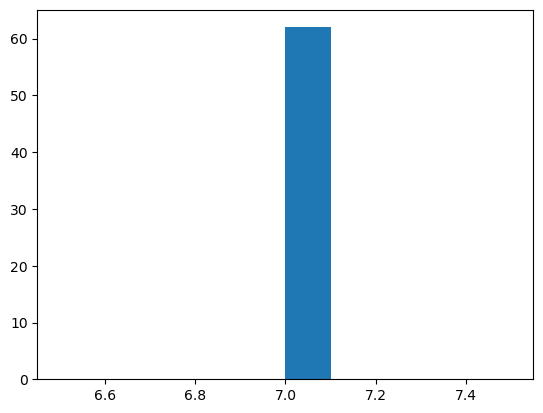

In [151]:
plt.hist(df_filt[df_filt['tdelta_12']<0]['processState']) 

## Monthly lookout: Time Series analysis Weekday vs Hour of the day and the configure latency 

TypeError: Invalid object type at position 0

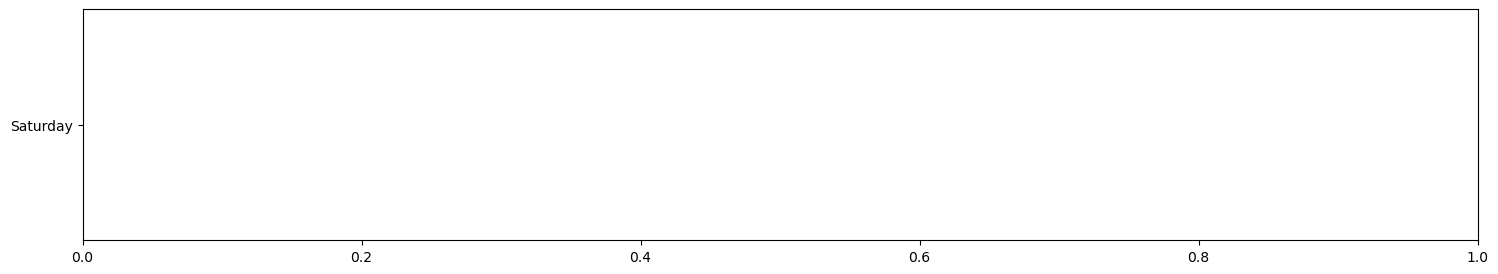

In [135]:
plt.figure(figsize=(18, 3))
sns.scatterplot(data=df_filt, x="tod", y=df_filt['weekday'].astype(str), hue="tdelta_12")

